In [1]:
import numpy as np
import pandas as pd

In [2]:
# df = pd.read_csv("spam.csv", encoding='utf-8') # fails if bytes don't fit valid UTF-8 pattern
# df = pd.read_csv("spam.csv", encoding='latin1') # never fails but may show wrong text
df = pd.read_csv("spam.csv", encoding='Windows-1252')  # chardet detected this encoding

In [3]:
# To detect encoding type in any file
%pip install chardet


Note: you may need to restart the kernel to use updated packages.


In [4]:
import chardet
with open('spam.csv', 'rb') as f: #IMP open in binary-mode
    text = f.read(5000)

encoding = chardet.detect(text)
print("encoder result: ", encoding)

encoder result:  {'encoding': 'Windows-1252', 'confidence': 0.7197765921973991, 'language': ''}


In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.shape

(5572, 5)

Steps We will be Performing:
> Data Cleaning  
> Exploratory Data Analysis (EDA)  
> Text Preprocessing  
> Model Building  
> Evaluation  
> Improvement  
> Website  
> Deploy

## 1. Data Cleaning
Includes:  
Dropping Unnecessary Columns,  
Renaming the columns if necessary,  
Encoding the target variable,  
Checking for missing values or duplicate values and act accordingly

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [8]:
df.drop(columns=['Unnamed: 2','Unnamed: 3', 'Unnamed: 4'], inplace=True) #IMP - I almost forgot inplace

In [9]:
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)

In [10]:
df.sample(5)

,target,text
1412,ham,"Wen ur lovable bcums angry wid u, dnt take it ..."
5102,spam,This msg is for your mobile content order It h...
4566,ham,But you were together so you should be thinkin...
641,ham,"said kiss, kiss, i can't do the sound effects..."
1793,ham,You bad girl. I can still remember them


In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
encoder = LabelEncoder()

df['target'] = encoder.fit_transform(df['target'])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df.isna().sum()

target    0
text      0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(403)

In [15]:
df.drop_duplicates(keep='first', inplace=True)

In [16]:
df.duplicated().sum()

np.int64(0)

## 2. Exploratory Data Analysis (EDA)

In [17]:
# 1. Check data imbalances
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x76e97886b980>,
 [Text(-1.014499732282844, 0.4251944181172162, 'ham'),
  Text(1.0144998708287172, -0.42519408755122207, 'spam')],
 [Text(-0.5533634903360967, 0.2319242280639361, '87.37'),
  Text(0.553363565906573, -0.231924047755212, '12.63')])

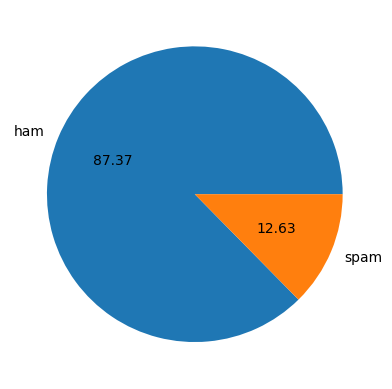

In [18]:
import matplotlib.pyplot as plt

plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')

In [19]:
# Data is imbalanced, We need to keep this in mind

# we will count no. of characters, words and sentences
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /home/sakshi-
[nltk_data]     khatiwada/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/sakshi-
[nltk_data]     khatiwada/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [20]:
df['number_of_characters'] = df['text'].apply(len)

In [21]:
df.head()

,target,text,number_of_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [22]:
df['number_of_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [23]:
df['number_of_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [24]:
df.head()

,target,text,number_of_characters,number_of_words,number_of_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [25]:
df[['number_of_characters', 'number_of_words', 'number_of_sentences']].describe()

,number_of_characters,number_of_words,number_of_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [26]:
df[df['target'] == 0][['number_of_characters', 'number_of_words', 'number_of_sentences']].describe() # ham's description

,number_of_characters,number_of_words,number_of_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [27]:
df[df['target'] == 1][['number_of_characters', 'number_of_words', 'number_of_sentences']].describe() # spam's description

,number_of_characters,number_of_words,number_of_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [28]:
import seaborn as sns

<Axes: xlabel='number_of_characters', ylabel='Count'>

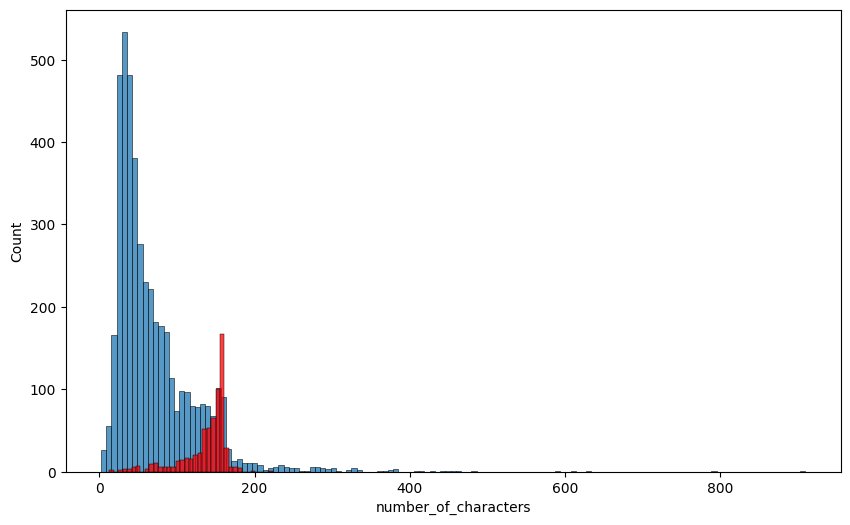

In [29]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['target'] == 0]['number_of_characters'])
sns.histplot(df[df['target'] == 1]['number_of_characters'], color='red')

<Axes: xlabel='number_of_words', ylabel='Count'>

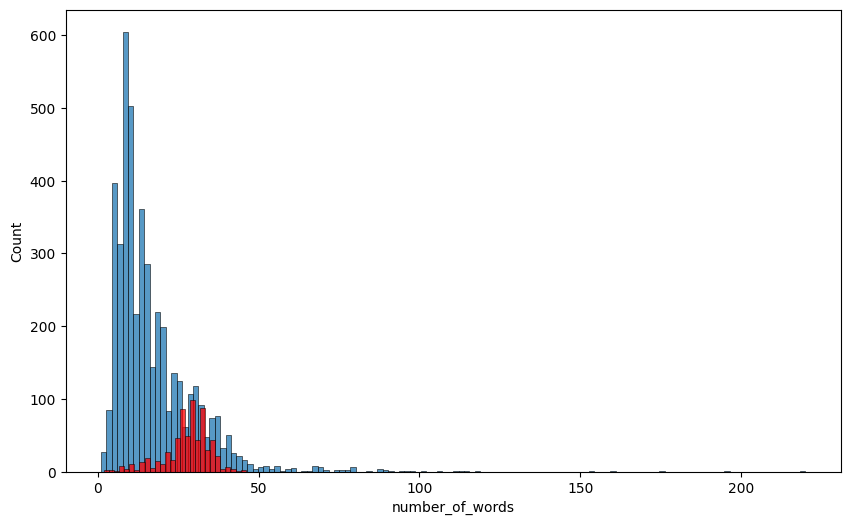

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['target'] == 0]['number_of_words'])
sns.histplot(df[df['target'] == 1]['number_of_words'], color='red')

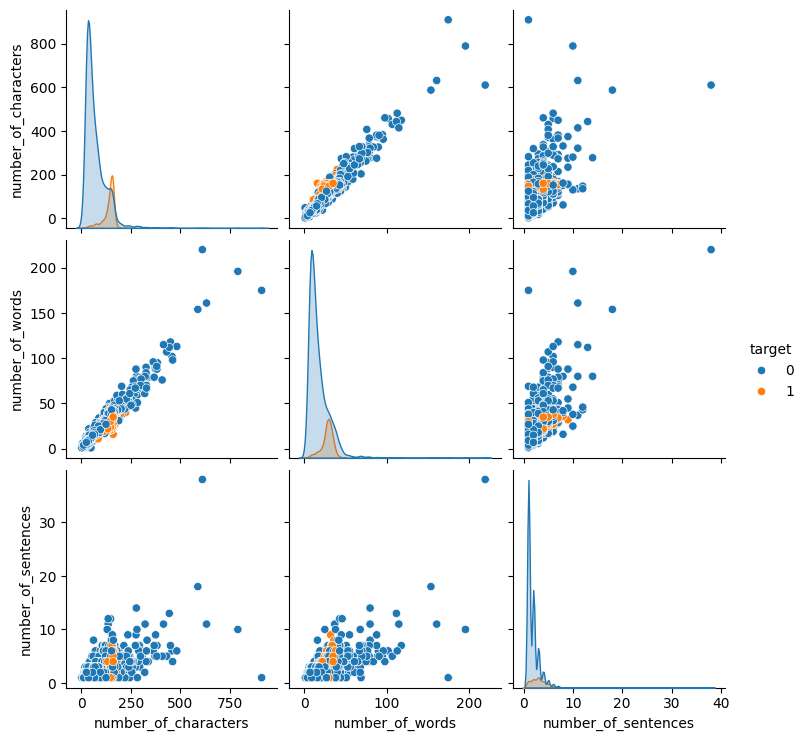

In [31]:
sns.pairplot(df, hue='target')

<Axes: >

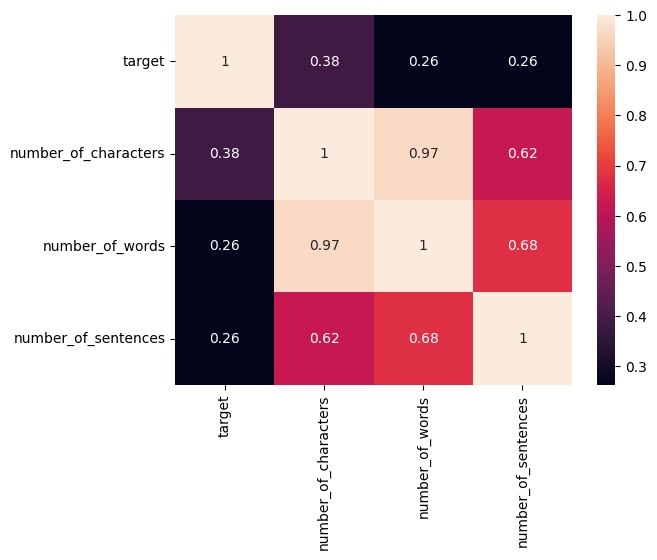

In [32]:
# sns.heatmap(df.corr()) # not supposed to throw error but did. Didn't implicitly ignored non-numeric column

# df.select_dtypes(include='number').corr()
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

## 3. Data Preprocessing

In [33]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer # Porter is the person who wrote this Stemming algorithm

In [34]:
ps = PorterStemmer()

In [35]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/sakshi-
[nltk_data]     khatiwada/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [36]:
import string

string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [37]:
# Starting with Transforming text
# lower case, tokenization, removing special characters, removing stop words and punctuations, stemming

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for word in text:
        if word.isalnum():
            y.append(word)
            
    text = y[:] # pitfall, this is list cloning. We can't directly assign a list to make a copy
    y.clear()
    
    for word in text:
        if word not in stopwords.words('english') and word not in string.punctuation:
            y.append(word)
            
            
    text = y[:]
    y.clear()
    
    for word in text:
        y.append(ps.stem(word))
        
    return " ".join(y)

In [38]:
transform_text("hi? i am having gathering saKSHI.")

'hi gather sakshi'

In [39]:
def transform_text_modified(text):
    """
    Preprocess the text and returns string
    """
    
    tokens_list = nltk.word_tokenize(text.lower())
    
    processed = []
    
    for word in tokens_list:
        if word.isalnum() and word not in stopwords.words('english') and word not in string.punctuation:
            processed.append(ps.stem(word))
    
    return " ".join(processed)

In [40]:
transform_text_modified("hi? i am having gathering saKSHI.")

'hi gather sakshi'

In [41]:
df['transformed_text'] = df['text'].apply(transform_text_modified)

### Word Cloud

In [42]:
from wordcloud import WordCloud

wc = WordCloud(height=500, width=500, min_font_size=8, background_color='white')

In [43]:
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=' '))
# ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=' ')) # Pitfall. If I use it like this, the wc is the same object, so it will override the previous wordcloud.

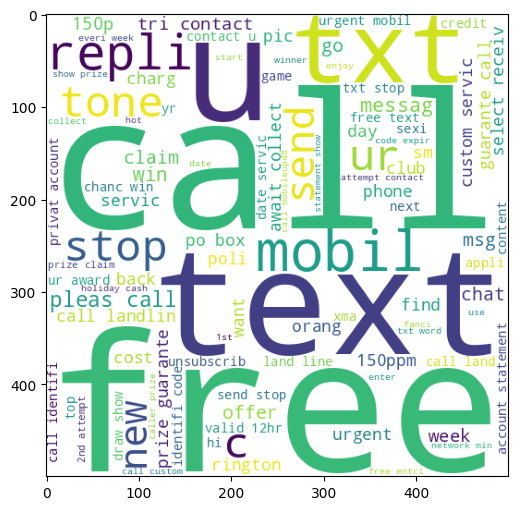

In [44]:
plt.figure(figsize=(10,6))
plt.imshow(spam_wc)

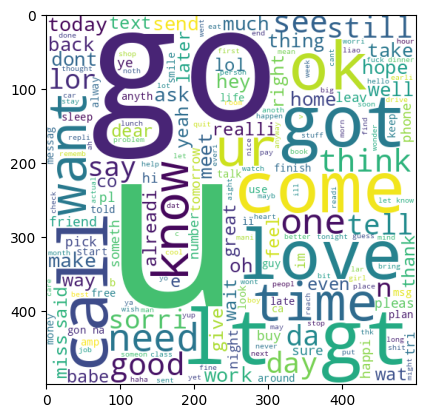

In [45]:
ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=' '))
plt.imshow(ham_wc)

In [46]:
df.head()

,target,text,number_of_characters,number_of_words,number_of_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [47]:
# Eventhough WordCloud clearly shows the top words, we are gonna find what are the top words anyway!
spam_words = []

for sentences in df[df['target'] == 1]['transformed_text'].tolist():
    for word in sentences.split(): # first split into a list, then retrieve every word
        spam_words.append(word)
        
spam_words

['free',
 'entri',
 '2',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 '21st',
 'may',
 'text',
 'fa',
 '87121',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 '08452810075over18',
 'freemsg',
 'hey',
 'darl',
 '3',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'kl341',
 'valid',
 '12',
 'hour',
 'mobil',
 '11',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 '08002986030',
 'six',
 'chanc',
 'win',
 'cash',
 '100',
 'pound',
 'txt',
 'csh11',
 'send',
 'cost',
 '6day',
 'tsandc',
 'appli',
 'repli',
 'hl',
 '4',
 'info',
 'urgent',
 '1',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 '81010',
 'c',
 'lccltd',
 'pobox',
 '4403ldnw

In [48]:
from collections import Counter

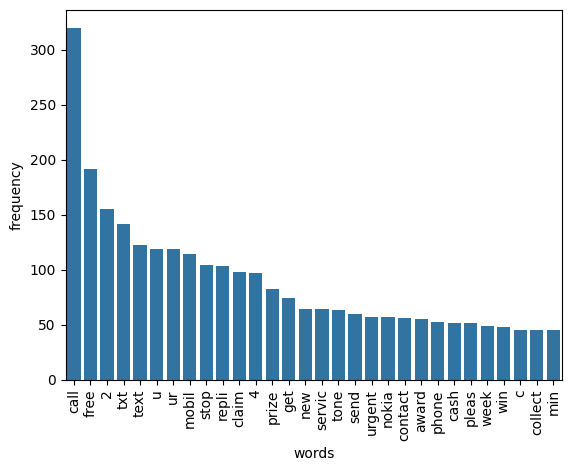

In [49]:
sns.barplot(x = pd.DataFrame(Counter(spam_words).most_common(30))[0],y= pd.DataFrame(Counter(spam_words).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.xlabel("words")
plt.ylabel("frequency")
plt.show()


In [50]:
ham_words = []

for sentences in df[df['target'] == 0]['transformed_text'].tolist():
    for word in sentences.split(): # first split into a list, then retrieve every word
        ham_words.append(word)
        
len(ham_words)

35404

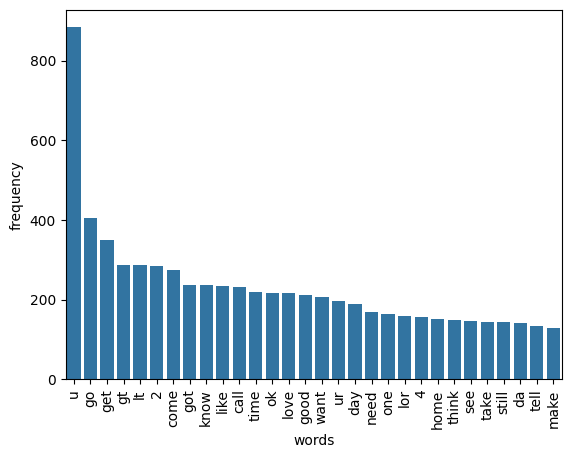

In [51]:
sns.barplot(x = pd.DataFrame(Counter(ham_words).most_common(30))[0],y= pd.DataFrame(Counter(ham_words).most_common(30))[1])
plt.xticks(rotation='vertical')
plt.xlabel("words")
plt.ylabel("frequency")
plt.show()

## 4. Model Buidling

In [124]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3200)

In [125]:
X = cv.fit_transform(df['transformed_text']).toarray() # sparse array object dinxa, teslai dense array ma convert garnu parxa
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(5169, 6708))

In [126]:
X = tfidf.fit_transform(df['transformed_text']).toarray() 
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 3200))

In [127]:
y = df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [135]:
from sklearn.preprocessing import MinMaxScaler # Standard scaler gives negative output too, NB doesn't take it
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [136]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

In [137]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [138]:
mnb = MultinomialNB()
bnb = BernoulliNB()
gnb = GaussianNB()

In [139]:
mnb.fit(X_train, y_train)
y_pred1 = mnb.predict(X_test)

bnb.fit(X_train, y_train)
y_pred2 = bnb.predict(X_test)

gnb.fit(X_train, y_train)
y_pred3 = gnb.predict(X_test)


In [ ]:
print("mnb model", accuracy_score(y_test, y_pred1))
print("confusion matrix: ", confusion_matrix(y_test, y_pred1))
print("precision score: ", precision_score(y_test, y_pred1))

print("bnb model", accuracy_score(y_test, y_pred2))
print("confusion matrix: ", confusion_matrix(y_test, y_pred2))
print("precision score: ", precision_score(y_test, y_pred2))

print("gnb model", accuracy_score(y_test, y_pred3))
print("confusion matrix: ", confusion_matrix(y_test, y_pred3))
print("precision score: ", precision_score(y_test, y_pred3))


# using cv
# mnb model 0.9748549323017408
# confusion matrix:  [[890  18]
#  [  8 118]]
# precision score:  0.8676470588235294

# bnb model 0.9748549323017408
# confusion matrix:  [[907   1]
#  [ 25 101]]
# precision score:  0.9901960784313726

# gnb model 0.8655705996131529
# confusion matrix:  [[785 123]
#  [ 16 110]]
# precision score:  0.4721030042918455

        #using tfidf, default max_features
        # mnb model 0.9680851063829787
        # confusion matrix:  [[908   0]
        #  [ 33  93]]
        # precision score:  1.0 ### perfect
        
        # max_features = 500
        # mnb model 0.9748549323017408
        # confusion matrix:  [[903   5]
        #  [ 21 105]]
        # precision score:  0.9545454545454546
        
        # mnb model 0.9535783365570599 # 100
        # confusion matrix:  [[898  10]
        #  [ 38  88]]
        # precision score:  0.8979591836734694
        
        # accuracy also improved: # 3000
        # mnb model 0.9777562862669246
        # confusion matrix:  [[908   0]
        #  [ 23 103]]
        # precision score:  1.0
                
                # this model improved both accuracy and precision, working better for max_features=3200
        # bnb model 0.9796905222437138
        # confusion matrix:  [[908   0]
        #  [ 21 105]]
        # precision score:  1.0
        
        # with scaling, stayed the same
                # bnb model 0.9796905222437138
                # confusion matrix:  [[908   0]
                #  [ 21 105]]
                # precision score:  1.0
                        

# bnb model 0.9748549323017408
# confusion matrix:  [[907   1]
#  [ 25 101]]
# precision score:  0.9901960784313726

# gnb model 0.8568665377176016
# confusion matrix:  [[785 123]
#  [ 25 101]]
# precision score:  0.45089285714285715



mnb model 0.9806576402321083
confusion matrix:  [[901   7]
 [ 13 113]]
precision score:  0.9416666666666667
bnb model 0.9796905222437138
confusion matrix:  [[908   0]
 [ 21 105]]
precision score:  1.0
gnb model 0.8636363636363636
confusion matrix:  [[783 125]
 [ 16 110]]
precision score:  0.46808510638297873


In [141]:
# continuing with tfidf vectorizer and MNB

## 5 Model Improvement

In [142]:
# 1. change the max_features parameter of TFIDF
# 2. using scaling

In [143]:
import pickle

pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(bnb, open('model.pkl', 'wb'))